<a target="_blank" href="https://colab.research.google.com/github/lukebarousse/Python_Data_Analytics_Course/blob/main/4_Problems/2_18_Matplotlib Box Plots.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

In [1]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

d:\Anaconda3\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 🟩 Data Scientist Hourly Salary Box Plot (2.18.1)

Text(0, 0.5, 'Hourly Salary ($USD)')

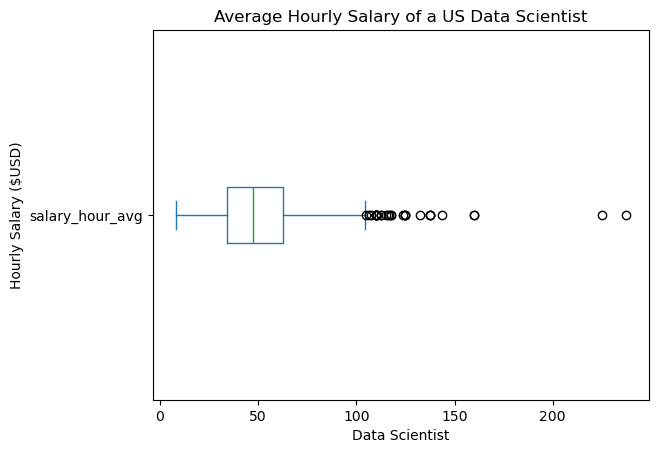

In [15]:
df_DS_US = df[(df['job_title_short'] == 'Data Scientist') &
              (df['job_country'] == 'United States')]
df_DS_US = df_DS_US.dropna(subset = ['salary_hour_avg']).reset_index()


df_DS_US['salary_hour_avg'].plot(kind = 'box', vert = False)
plt.title('Average Hourly Salary of a US Data Scientist')
plt.xlabel('Data Scientist')
plt.ylabel('Hourly Salary ($USD)')

#ax = plt.gca()
#ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}K'))


---

## 🟨 Comparison of Hourly Salaries for Data Analyst (2.18.2)

C:\Users\frase\AppData\Local\Temp\ipykernel_1320\3214609421.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(df_list, labels = countries)


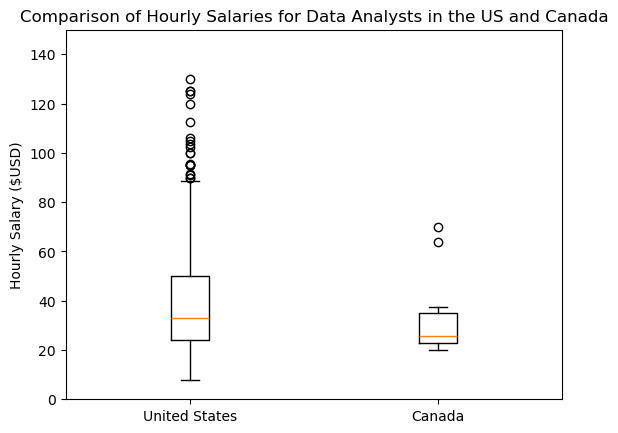

In [35]:
# Code Needed
countries = ['United States', 'Canada']

df_DA = df[(df['job_title_short'] == 'Data Analyst') &
           (df['job_country'].isin(countries))
           ]
df_DA = df_DA.dropna(subset = ['salary_hour_avg'])

df_list = [df_DA[df_DA['job_country'] == country]['salary_hour_avg'] for country in countries]

plt.boxplot(df_list, labels = countries)
plt.xlabel('')
plt.ylabel('Hourly Salary ($USD)')
plt.ylim(0, 150)
plt.title('Comparison of Hourly Salaries for Data Analysts in the US and Canada')
plt.show()





---

## 🟥 Comparison of Hourly Salaries in Canada (2.18.3)

C:\Users\frase\AppData\Local\Temp\ipykernel_10996\2406953689.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(df_list, labels = job_titles)


Text(0, 0.5, 'Hourly Salary ($USD)')

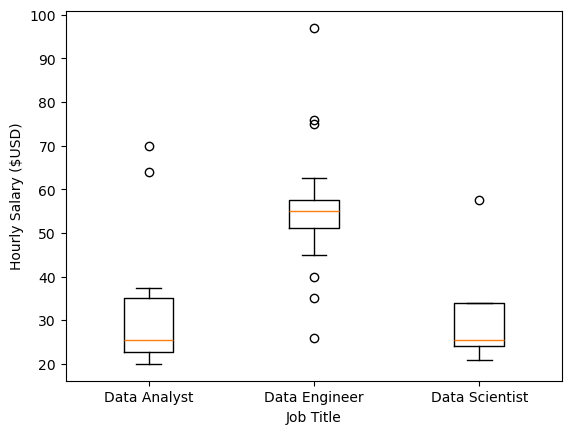

In [7]:
# Code Needed
job_titles = ['Data Analyst', 'Data Engineer', 'Data Scientist']
df_filtered = df[(df['job_country'] == 'Canada')
                 & df['job_title_short'].isin(job_titles)]
df_filtered = df_filtered.dropna(subset = ['salary_hour_avg']).reset_index()

df_list = [
    df_filtered[df_filtered['job_title_short'] == job_title]['salary_hour_avg'] for job_title in job_titles
]
plt.boxplot(df_list, labels = job_titles)
plt.xlabel('Job Title')
plt.ylabel('Hourly Salary ($USD)')




---